# Demo of calibrated explanations on the speeddating dataset
Author: Tuwe Löfström (tuwe.lofstrom@ju.se)  
Copyright 2023 Tuwe Löfström  
License: BSD 3 clause

Sources:
1. [Summary on the robustness of interpretability methods [Medium]](https://medium.com/@mohamadt/summary-on-the-robustness-of-interpretability-methods-ffb26ba22776)
2. [On the Robustness of Interpretability Methods [Arxiv]](https://arxiv.org/pdf/1806.08049.pdf)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import time
import warnings

warnings.filterwarnings("ignore", category=UserWarning)


import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

from calibrated_explanations import WrapCalibratedExplainer, __version__

print(f"calibrated_explanations {__version__}")

calibrated_explanations v0.11.1


In [3]:
dataset = "speeddating"
delimiter = ","

filename = "../../data/" + dataset + ".csv"
df = pd.read_csv(filename, delimiter=delimiter)
df = df.dropna()
df = df.drop(["has_null"], axis=1)
target = "match"

In [8]:
categorical_features = []
categorical_labels = {}
for c, col in enumerate(df.columns):
    if df[col].dtype == 'object' or df[col].dtype.name == 'str':
        df[col] = df[col].str.replace("'", "")
        if col != target:
            categorical_features.append(c)
            categorical_labels[c] = dict(zip(range(len(np.unique(df[col]))), np.unique(df[col]), strict=False))
        mapping = dict(zip(np.unique(df[col]), range(len(np.unique(df[col]))), strict=False))
        df[col] = df[col].map(mapping)
print(categorical_labels)

{1: {0: 'female', 1: 'male'}, 5: {0: '[0-1]', 1: '[2-3]', 2: '[4-6]', 3: '[7-37]'}, 6: {0: 'Asian/Pacific Islander/Asian-American', 1: 'Black/African American', 2: 'European/Caucasian-American', 3: 'Latino/Hispanic American', 4: 'Other'}, 7: {0: 'Asian/Pacific Islander/Asian-American', 1: 'Black/African American', 2: 'European/Caucasian-American', 3: 'Latino/Hispanic American', 4: 'Other'}, 8: {0: '0', 1: '1'}, 11: {0: '[0-1]', 1: '[2-5]', 2: '[6-10]'}, 12: {0: '[0-1]', 1: '[2-5]', 2: '[6-10]'}, 13: {0: 'Applied Maths/Econs', 1: 'Art History/medicine', 2: 'Biomedical Engineering', 3: 'Business', 4: 'Business & International Affairs', 5: 'Business [MBA]', 6: 'Business- MBA', 7: 'Chemistry', 8: 'Classics', 9: 'Communications', 10: 'Computer Science', 11: 'Economics', 12: 'Economics and Political Science', 13: 'Economics; Sociology', 14: 'Educational Psychology', 15: 'Electrical Engineering', 16: 'Elementary/Childhood Education [MA]', 17: 'Engineering', 18: 'English', 19: 'Film', 20: 'Fin

In [9]:
df.head()

,wave,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,importance_same_race,...,d_expected_num_interested_in_me,d_expected_num_matches,like,guess_prob_liked,d_like,d_guess_prob_liked,met,decision,decision_o,match
0,1.0,0,21.0,27.0,6.0,2,0,2,0,2.0,...,0,1,7.0,6.0,1,1,0.0,1,0,0
1,1.0,0,21.0,22.0,1.0,0,0,2,0,2.0,...,0,1,7.0,5.0,1,1,1.0,1,0,0
3,1.0,0,21.0,23.0,2.0,1,0,2,0,2.0,...,0,1,7.0,6.0,1,1,0.0,1,1,1
4,1.0,0,21.0,24.0,3.0,1,0,3,0,2.0,...,0,1,6.0,6.0,1,1,0.0,1,1,1
5,1.0,0,21.0,25.0,4.0,2,0,2,0,2.0,...,0,1,6.0,5.0,1,1,0.0,0,1,0


In [10]:
num_to_test = 10

X, y = df.drop(target, axis=1), df[target]
no_of_classes = len(np.unique(y))
no_of_features = X.shape[1]
no_of_instances = X.shape[0]
# sort targets to make sure equal presence of both classes in test set (see definition of test_index after outer loop below)
idx = np.argsort(y.values).astype(int)
X, y = X.values[idx, :], y.values[idx]
# Select num_to_test/2 from top and num_to_test/2 from bottom of list of instances
test_index = np.array(
    [
        *range(int(num_to_test / 2)),
        *range(no_of_instances - 1, no_of_instances - int(num_to_test / 2) - 1, -1),
    ]
)
train_index = np.setdiff1d(np.array(range(no_of_instances)), test_index)
x_train, x_test = X[train_index, :], X[test_index, :]
y_train, y_test = y[train_index], y[test_index]
# x_train,y_train = shuffle(x_train, y_train)
x_train, x_cal, y_train, y_cal = train_test_split(
    x_train, y_train, test_size=0.33, random_state=42, stratify=y_train
)
print(y_test)

[0 0 0 0 0 1 1 1 1 1]


In [11]:
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=0)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      0.80      0.89         5

    accuracy                           0.90        10
   macro avg       0.92      0.90      0.90        10
weighted avg       0.92      0.90      0.90        10



In [12]:
tic = time.time()
explainer = WrapCalibratedExplainer(model)
explainer.calibrate(x_cal, y_cal, feature_names=df.columns, categorical_features=categorical_features, categorical_labels=categorical_labels)
print(f"Time taken: {(time.time()-tic)/num_to_test}")

Time taken: 0.008234357833862305


C:\Users\loftuw\AppData\Local\Python\pythoncore-3.14-64\Lib\importlib\__init__.py:88: UserWarning: Cache backend fallback: using minimal in-package LRU/TTL implementation due to missing 'cachetools'
  return _bootstrap._gcd_import(name[level:], package, level)


In [13]:
tic = time.time()
alternative_explanation = explainer.explore_alternatives(x_test)
print(f"Time taken to generate alternative rules per instance: {(time.time()-tic)/num_to_test}")

Time taken to generate alternative rules per instance: 0.03934731483459473


c:\Users\loftuw\Documents\Github\moffran-calibrated_explanations\calibrated_explanations\venv-wheel\Lib\site-packages\calibrated_explanations\legacy\plotting.py:618: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
c:\Users\loftuw\Documents\Github\moffran-calibrated_explanations\calibrated_explanations\venv-wheel\Lib\site-packages\calibrated_explanations\legacy\plotting.py:618: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
c:\Users\loftuw\Documents\Github\moffran-calibrated_explanations\calibrated_explanations\venv-wheel\Lib\site-packages\calibrated_explanations\legacy\plotting.py:618: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
c:\Users\loftuw\Documents\Github\moffran-calibrated_explanations\calibrated_explanations\venv-wheel\Lib\site-packages\calibrated_explanations\legacy\plotting.py:618: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
 

Time taken plotting alternative rules per instance: 0.2125770092010498
Time taken constructing conjunctive rules per instance: 1.150973868370056


c:\Users\loftuw\Documents\Github\moffran-calibrated_explanations\calibrated_explanations\venv-wheel\Lib\site-packages\calibrated_explanations\legacy\plotting.py:618: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
c:\Users\loftuw\Documents\Github\moffran-calibrated_explanations\calibrated_explanations\venv-wheel\Lib\site-packages\calibrated_explanations\legacy\plotting.py:618: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
c:\Users\loftuw\Documents\Github\moffran-calibrated_explanations\calibrated_explanations\venv-wheel\Lib\site-packages\calibrated_explanations\legacy\plotting.py:618: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
c:\Users\loftuw\Documents\Github\moffran-calibrated_explanations\calibrated_explanations\venv-wheel\Lib\site-packages\calibrated_explanations\legacy\plotting.py:618: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
 

Time taken plotting alternative and conjunctive rules per instance: 0.0864060640335083


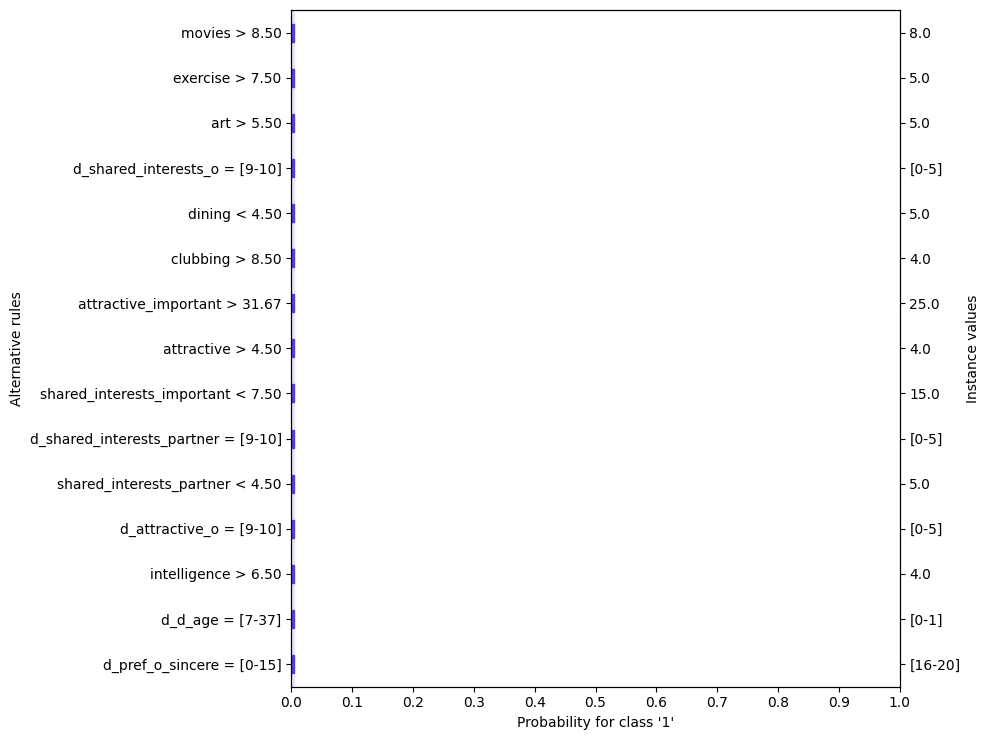

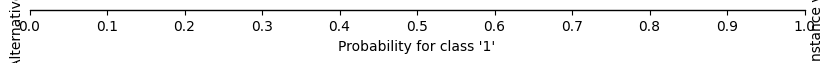

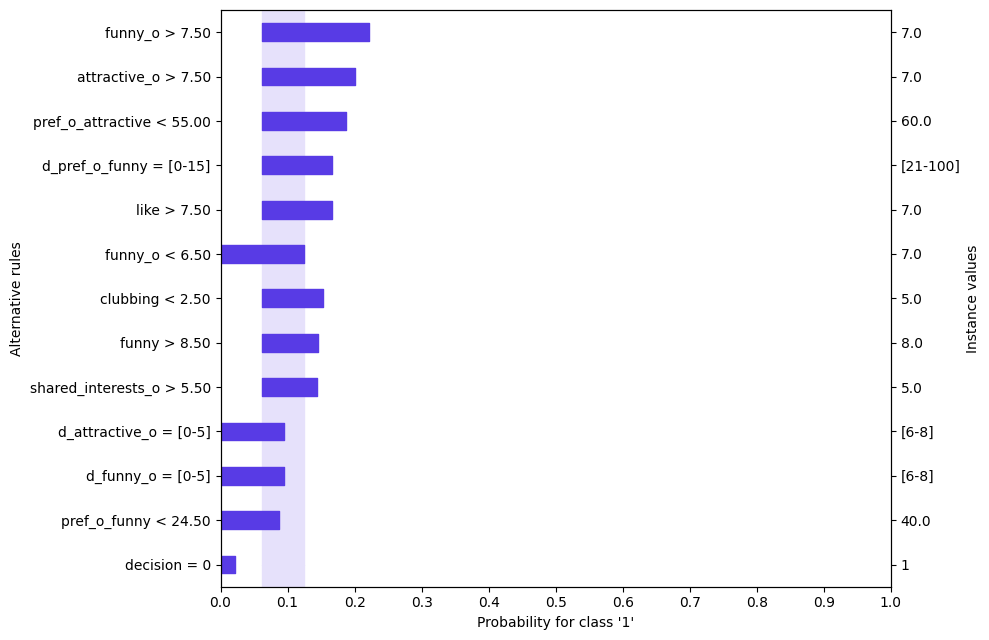

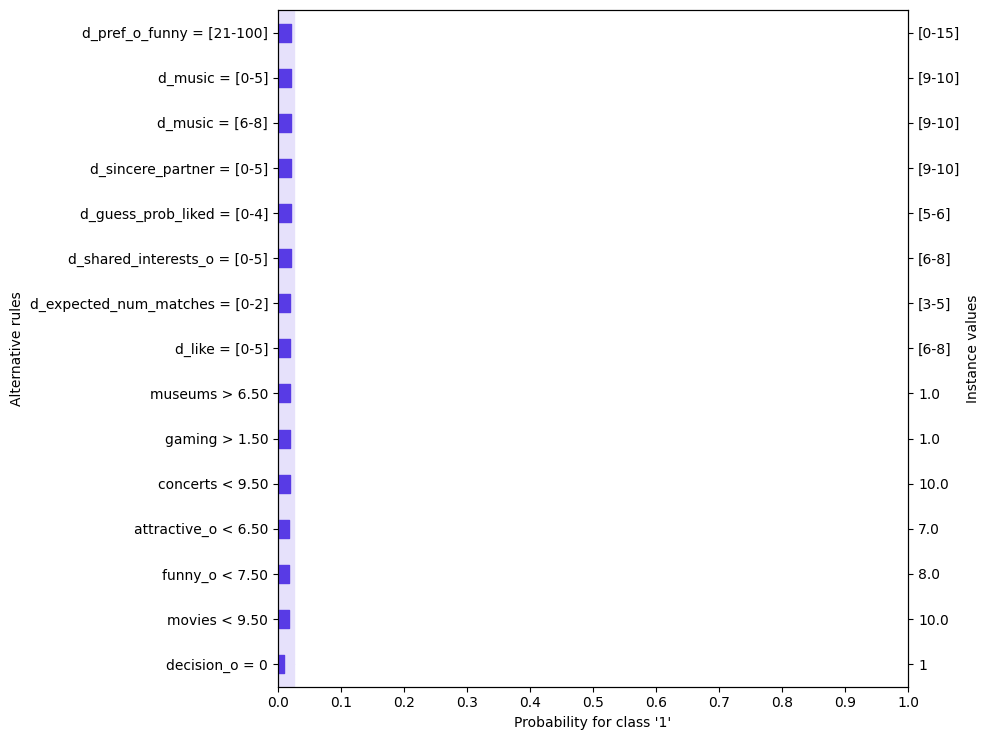

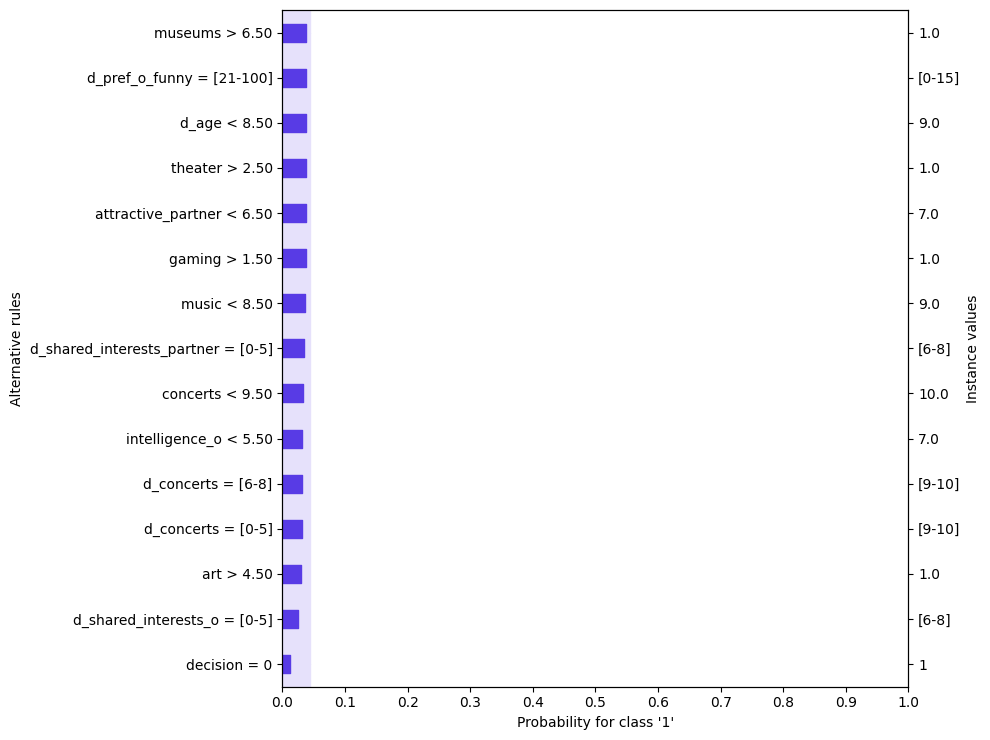

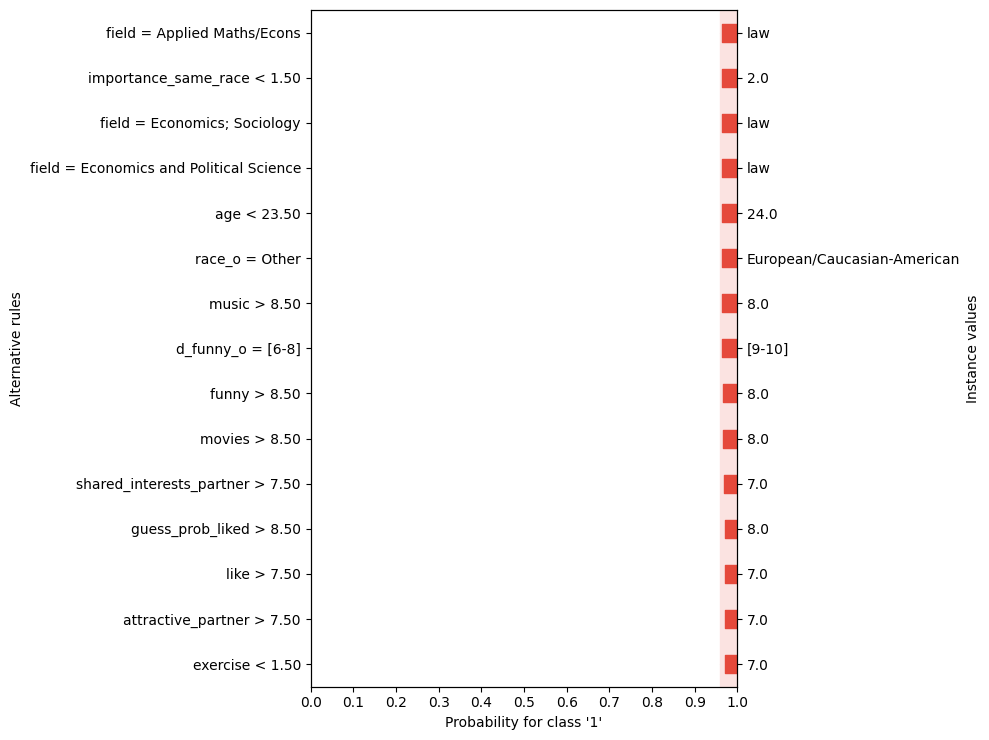

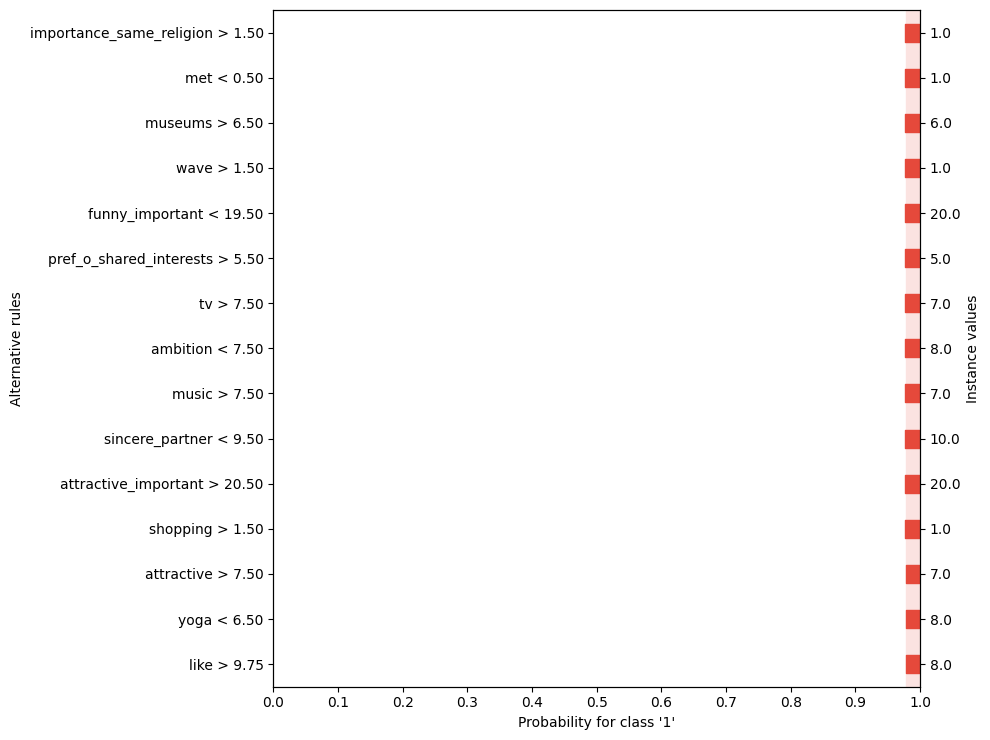

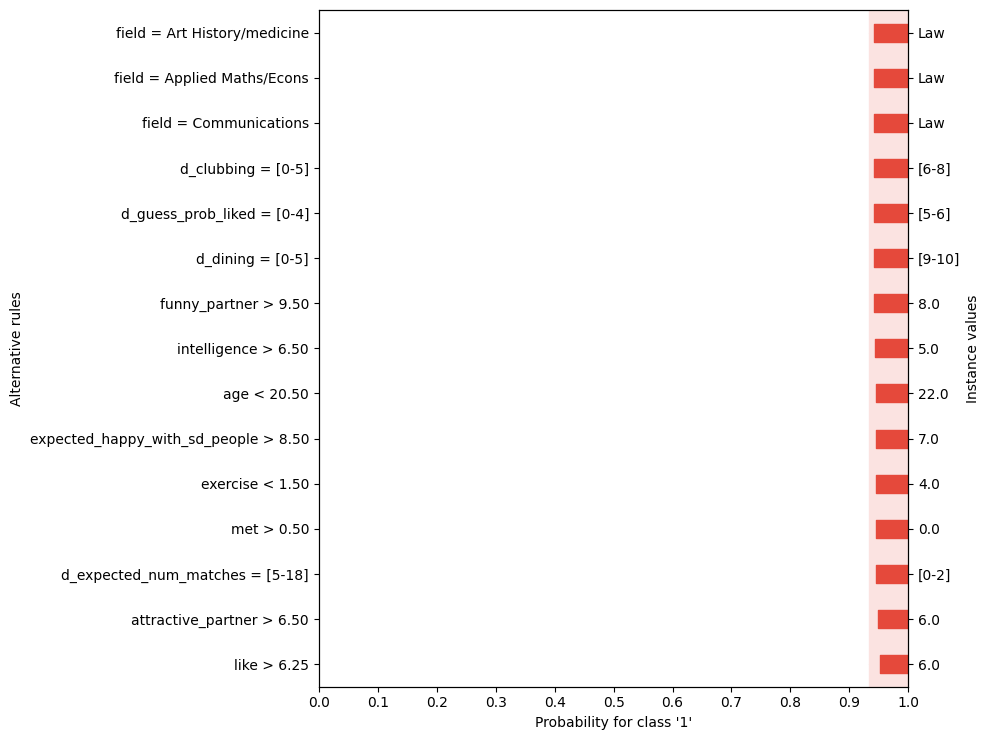

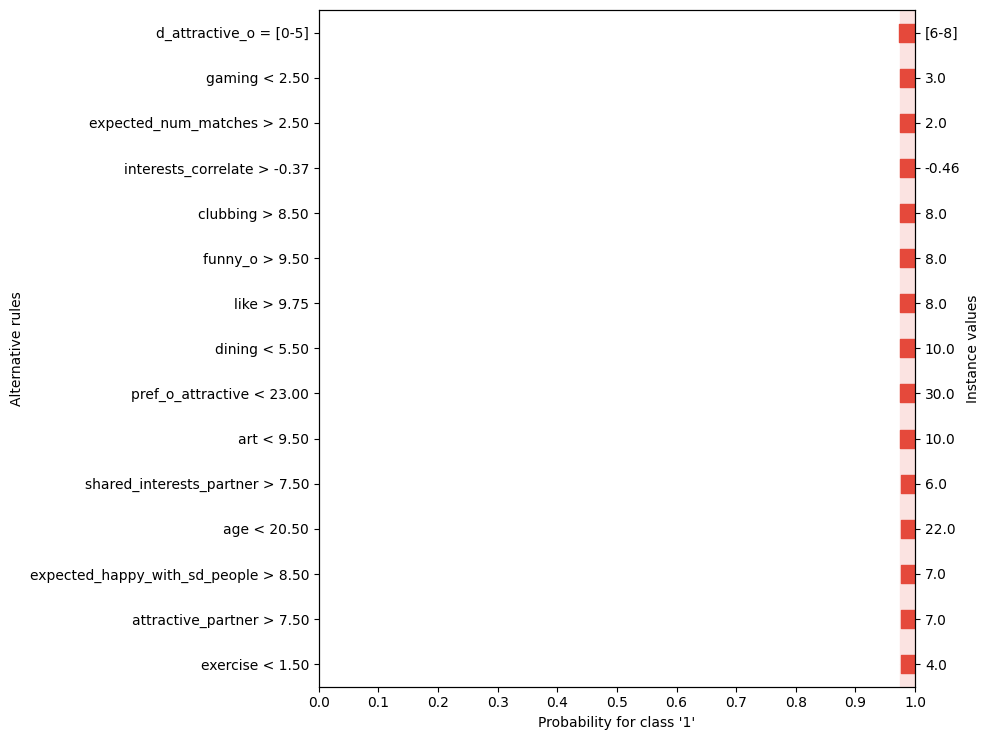

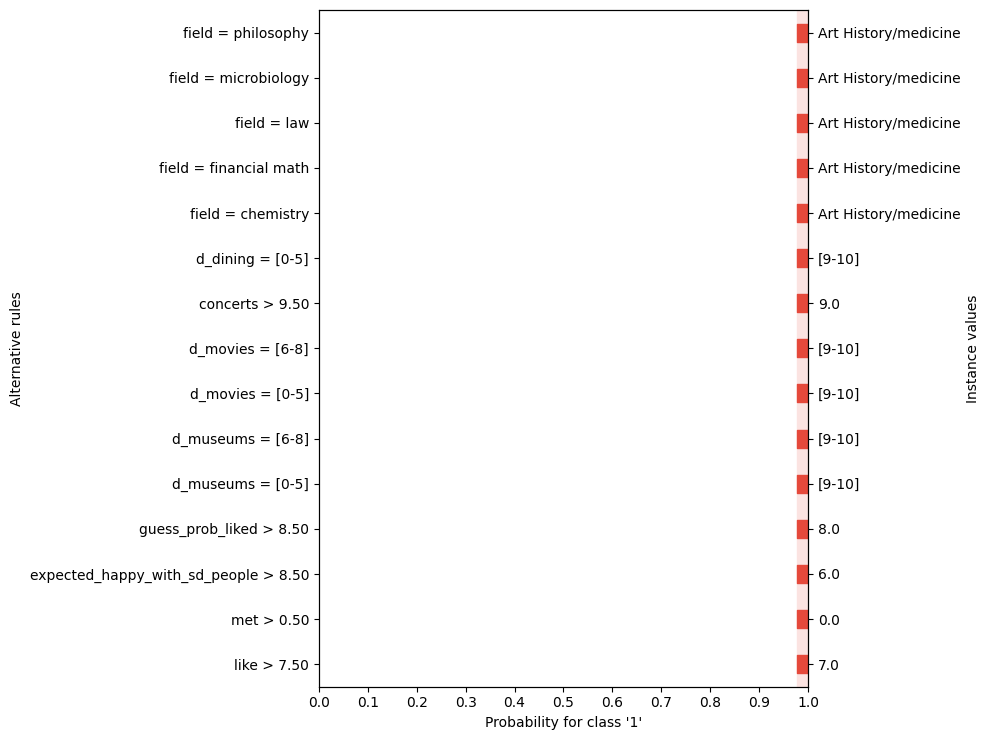

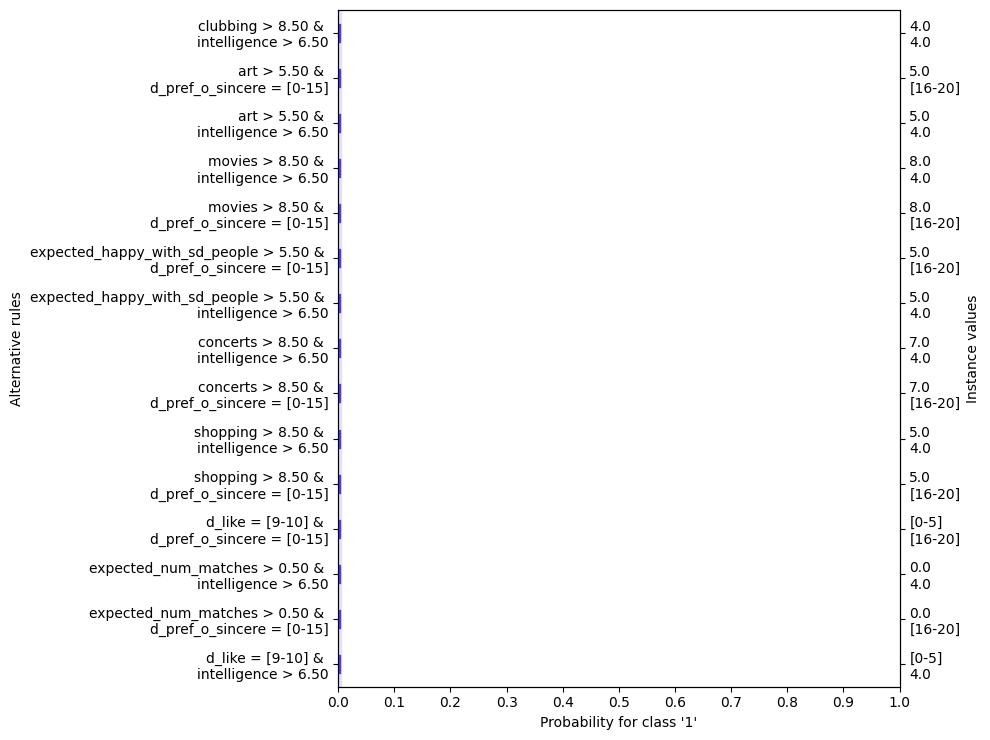

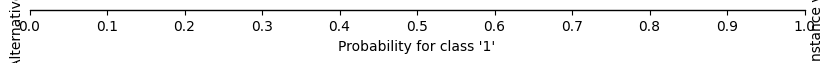

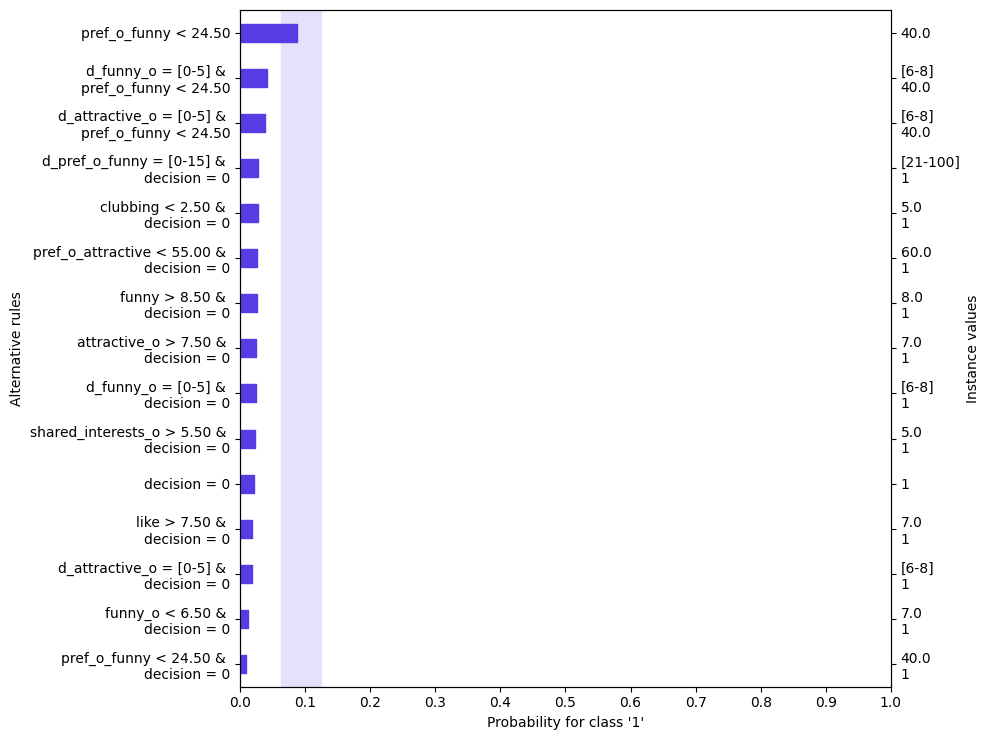

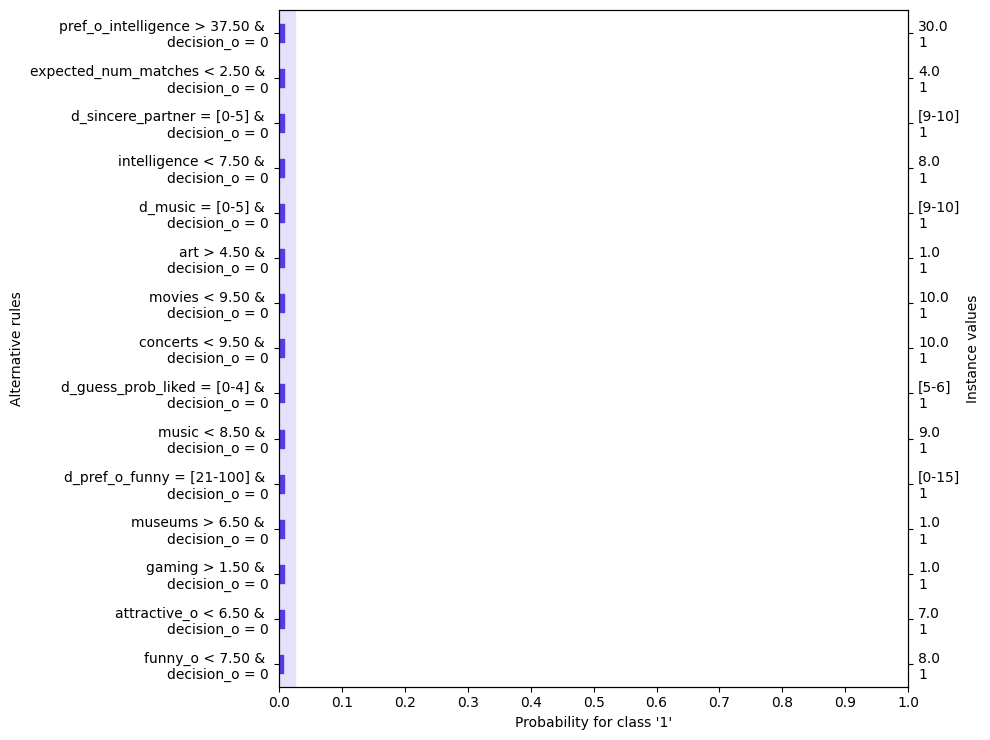

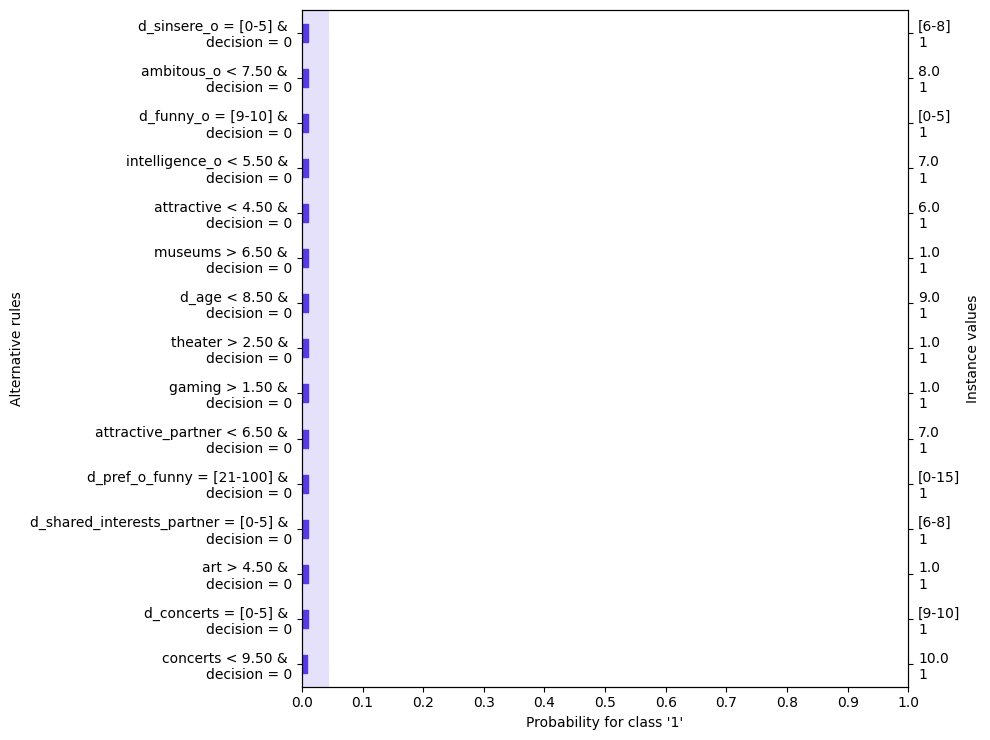

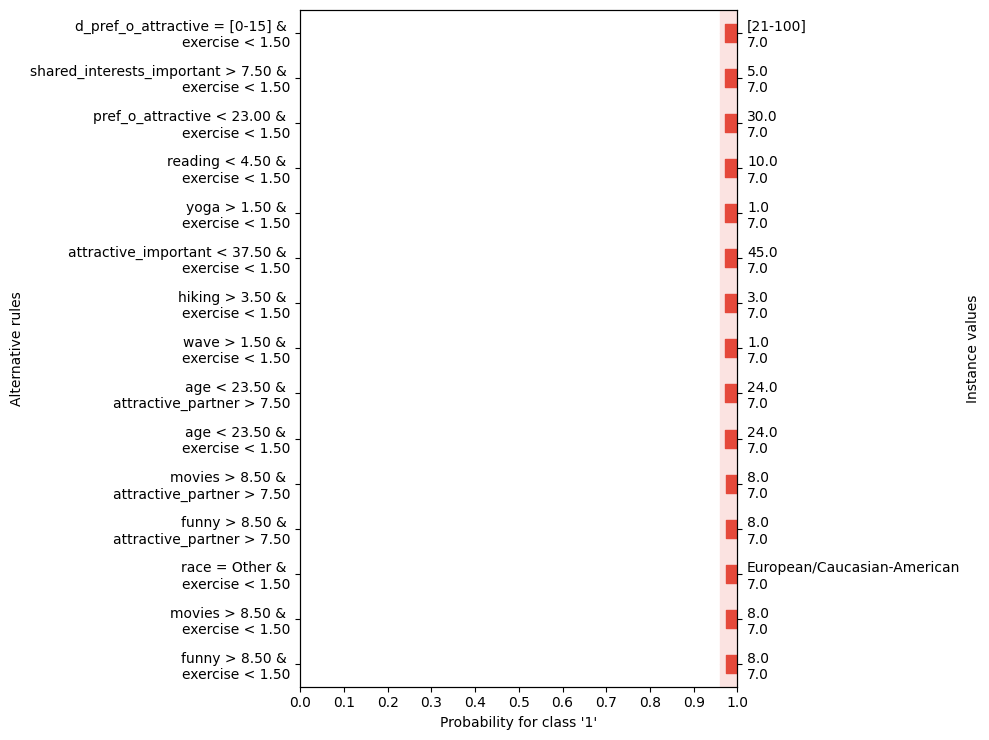

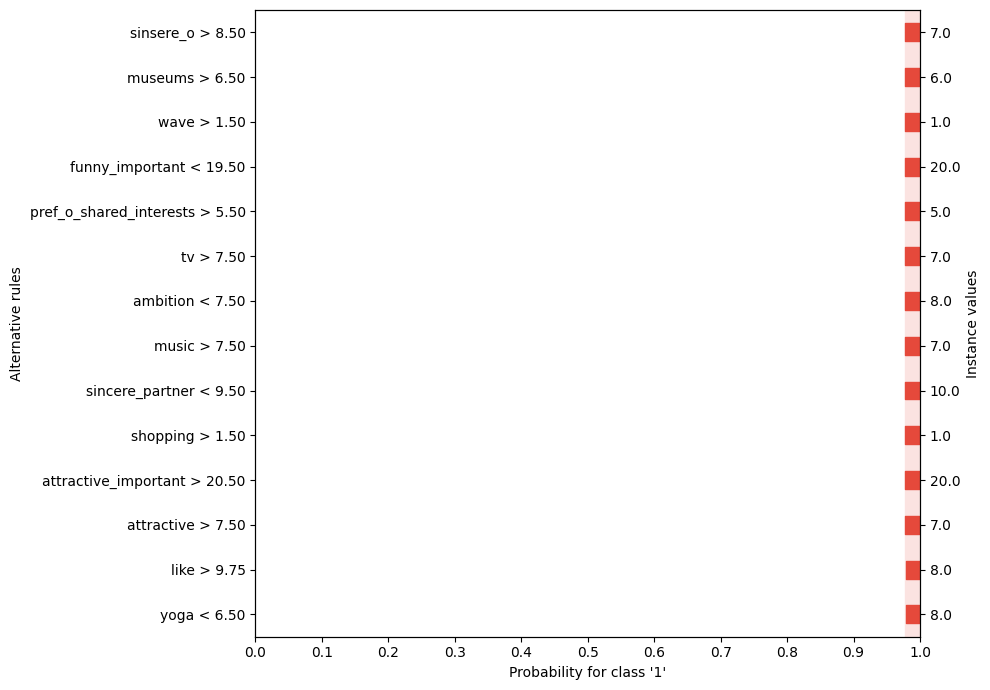

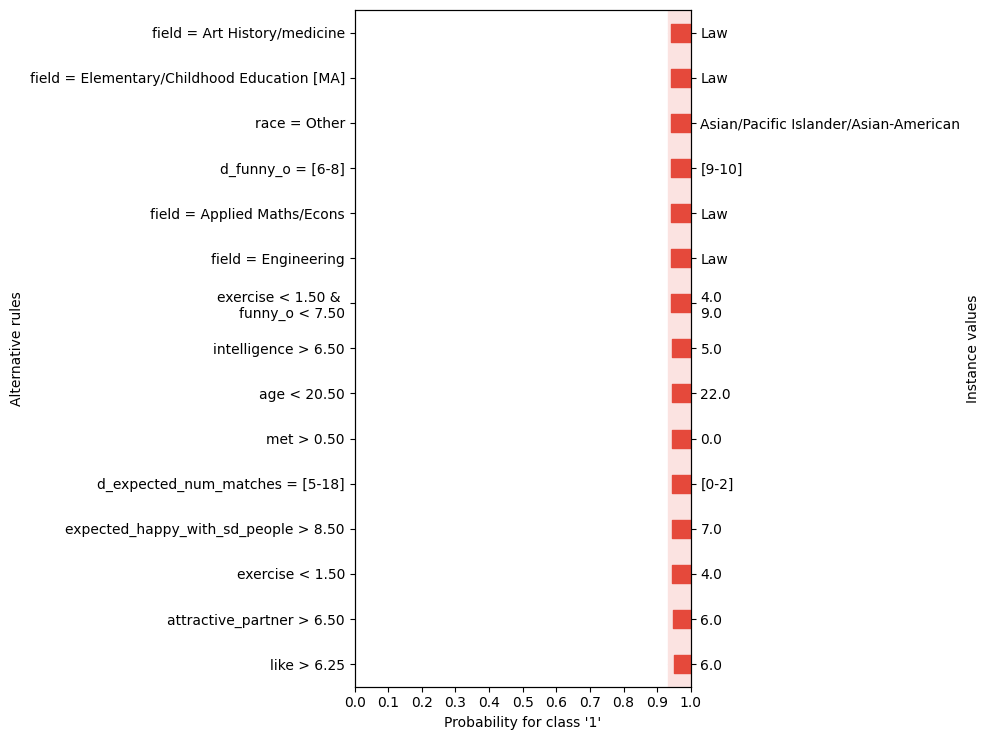

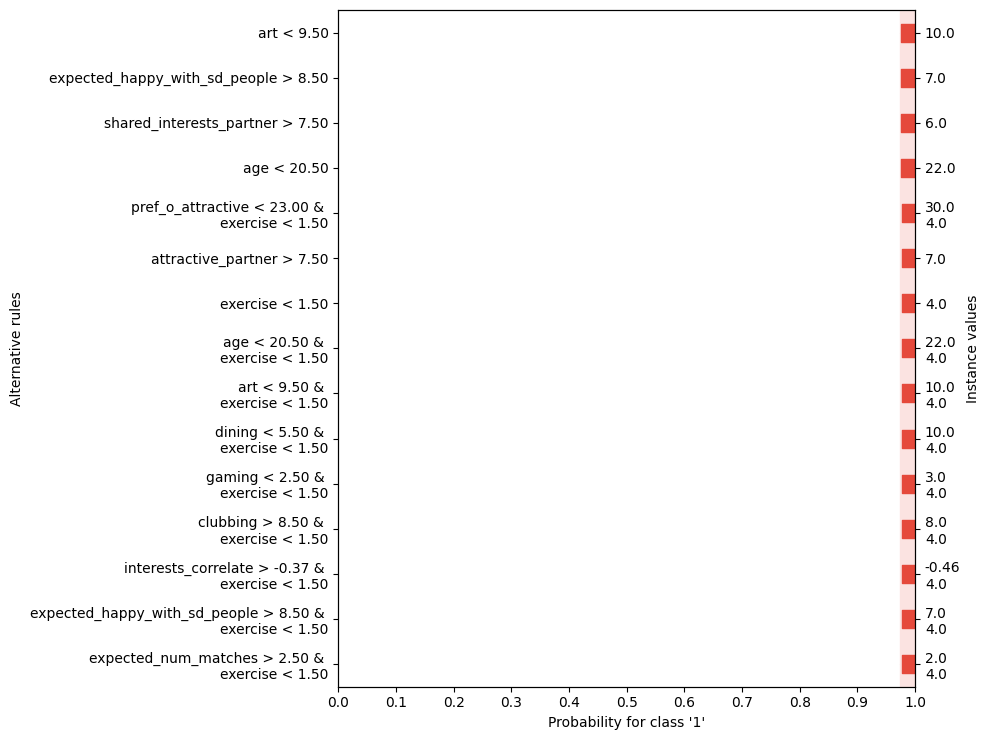

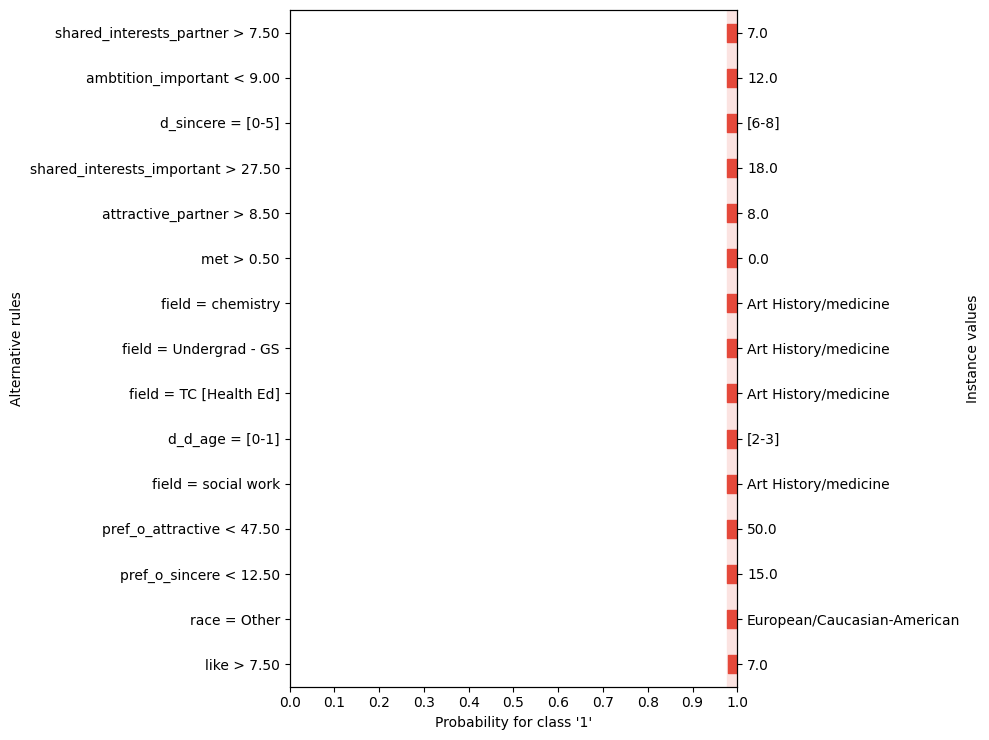

In [14]:
tic = time.time()
alternative_explanation.plot(filter_top=15)
print(f"Time taken plotting alternative rules per instance: {(time.time()-tic)/num_to_test}")
tic = time.time()
exp = alternative_explanation.add_conjunctions()
print(f"Time taken constructing conjunctive rules per instance: {(time.time()-tic)/num_to_test}")
tic = time.time()
alternative_explanation.plot(filter_top=15)
print(
    f"Time taken plotting alternative and conjunctive rules per instance: {(time.time()-tic)/num_to_test}"
)

In [15]:
y_pred = model.predict(x_test)
y_proba = model.predict_proba(x_test)
print("Performance of underlying model on test set")
print(classification_report(y_test, y_pred, target_names=df[target].unique().astype(str)))
y_va = [
    int(va > 0.5) for va in [e.prediction["predict"] for e in alternative_explanation.explanations]
]
print("Performance of calibration model on test set")
print(classification_report(y_test, y_va, target_names=df[target].unique().astype(str)))
print("target, model pred, model prob, va pred, va prob")
print(
    *zip(
        y_test,
        y_pred,
        y_proba[:, 1],
        y_va,
        [e.prediction["predict"] for e in alternative_explanation.explanations], strict=False,
    ),
    sep="\n",
)

Performance of underlying model on test set
              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      0.80      0.89         5

    accuracy                           0.90        10
   macro avg       0.92      0.90      0.90        10
weighted avg       0.92      0.90      0.90        10

Performance of calibration model on test set
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10

target, model pred, model prob, va pred, va prob
(np.int64(0), np.int64(0), np.float64(0.018225742312110813), 0, np.float64(0.004201680672268907))
(np.int64(0), np.int64(0), np.float64(0.009913479629259899), 0, np.float64(0.0038461538461538464))
(np.int64(0